# Total-field/scattered-field (TFSF) sources

This notebook shows how to use `fdtdx.TFSFPlaneSourceRegion`, a box-shaped source that sends a plane wave through the inside of a closed surface and leaves only scattered light outside. We build one, check that an empty box stays dark outside, and then put a silicon cube in the box to look at its scattered field.

## 1. Why a TFSF source?

Say you want the scattering cross-section of a nanoparticle, the radar cross-section of an object, or the diffraction efficiency of a grating. The simulation has to do two things. It has to illuminate the object with a clean plane wave, and it has to let you look at the scattered light without the much stronger incident wave on top of it.

A plain plane source (`fdtdx.UniformPlaneSource`) launches a wave from one plane and lets it travel on. That works as an illuminator, but incident and scattered light overlap everywhere behind the source plane, so there is no region where you can read off the scattered field alone. The wave also reflects off finite side walls unless the sides are periodic, which turns the setup into an infinite sheet.

The total-field/scattered-field method avoids both problems. You draw a closed box around the object and add a correction on every face of the box. The correction equals the incident field and has a sign chosen so that

- inside the box, the field is the total field (incident plus scattered),
- outside the box, the incident wave is cancelled and only the scattered field remains. If nothing inside scatters, the field outside is zero.

The scattered light then leaves through ordinary PML, and the region outside the box can be used directly for far-field projections or cross-section calculations. The sketch below shows the geometry.

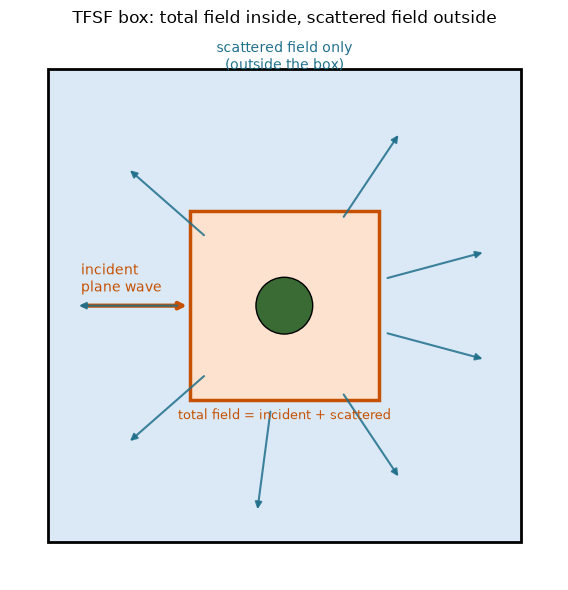

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6))

# Outer simulation domain, terminated in ordinary PML
outer = patches.Rectangle((-5, -5), 10, 10, linewidth=2, edgecolor="black",
                           facecolor="#dbe9f6")
ax.add_patch(outer)

# TFSF box: total field lives inside this surface
box = patches.Rectangle((-2, -2), 4, 4, linewidth=2.5, edgecolor="#c65102",
                         facecolor="#fde3cf")
ax.add_patch(box)

# a scatterer sitting inside the box
scatterer = patches.Circle((0, 0), 0.6, facecolor="#3a6b35", edgecolor="black")
ax.add_patch(scatterer)

# incident wave entering through the box's left face
ax.annotate("", xy=(-2, 0), xytext=(-4.3, 0),
            arrowprops=dict(arrowstyle="-|>", color="#c65102", lw=3))
ax.text(-4.3, 0.3, "incident\nplane wave", color="#c65102", fontsize=10, ha="left")

# scattered field radiating outward through the box boundary in every direction
for ang in np.linspace(15, 345, 9):
    if 80 < ang < 100:
        continue
    rad = np.deg2rad(ang)
    x0, y0 = 2.2 * np.cos(rad), 2.2 * np.sin(rad)
    x1, y1 = 4.4 * np.cos(rad), 4.4 * np.sin(rad)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="#1f6f8b", lw=1.5, alpha=0.85))

ax.text(0, 5.0, "scattered field only\n(outside the box)", color="#1f6f8b",
        fontsize=10, ha="center")
ax.text(0, -2.4, "total field = incident + scattered", color="#c65102",
        fontsize=9, ha="center")

ax.set_xlim(-5.8, 5.8)
ax.set_ylim(-5.8, 5.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("TFSF box: total field inside, scattered field outside")
plt.tight_layout()
plt.show()

## 2. TFSF sources in fdtdx

`UniformPlaneSource`, `GaussianPlaneSource` and `ModePlaneSource` all build on the base class `TFSFPlaneSource`. It applies the TFSF correction on a single plane, which is how these sources send a wave in one direction only.

`fdtdx.TFSFPlaneSourceRegion` applies the same correction on all faces of a box.

It is a volume object with an explicit `propagation_axis`. By default it injects on all six faces: the two faces perpendicular to the propagation axis launch and terminate the wave, and the four side faces keep it inside the box.

## 3. Setting up the simulation

We start like any other fdtdx simulation, with a random key, a `SimulationConfig` and a `SimulationVolume`. The key is required by the API, although this simulation is deterministic.

Two choices in the config matter later. The grid spacing is 50 nm, about 31 cells per vacuum wavelength. The simulation time is 150 fs, enough for a short pulse to cross the box and for the scattered light to reach the PML.

In [7]:
import time

import jax
import jax.numpy as jnp
from IPython.display import Video

import fdtdx
%matplotlib inline

In [9]:
# Random key for FDTDX
key = jax.random.PRNGKey(seed=42)

object_list = []

# Duration, spatial resolution, numeric dtype and Courant stability factor
config = fdtdx.SimulationConfig(
    time=150e-15,
    grid=fdtdx.UniformGrid(spacing=50e-9),
    dtype=jnp.float32,
    courant_factor=0.99,
)

In [11]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(9e-6, 9e-6, 9e-6),
    material=fdtdx.Material(  # background material = vacuum/air
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)

The TFSF box supplies its own plane wave on all of its faces, so the simulation boundaries do not need to be periodic. A `UniformPlaneSource` usually needs periodic or Bloch boundaries on the sides, so that the wave does not hit finite side walls. Here we can simply use PML on all six sides. At 50 nm spacing, 20 PML cells are 1 µm thick.

In [14]:
constraints = []

# PML on all six sides, no periodic boundaries needed for a TFSF box.
pml_cells = 20
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(boundary_type="pml", thickness=pml_cells)
bound_dict, bc_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)
constraints.extend(bc_constraints)
object_list.extend(bound_dict.values())

## 4. The TFSF box

These are the constructor arguments you will use most often.

| Parameter | Meaning |
|---|---|
| `propagation_axis` | Grid axis the wave travels along (`0` = x, `1` = y, `2` = z). Required, because a box has no thin axis to infer it from. |
| `direction` | `"+"` or `"-"`: the direction of travel along `propagation_axis`. |
| `wave_character` | A `fdtdx.WaveCharacter`. Give it a `wavelength`, `period` or `frequency` (only one of them), plus an optional `phase_shift`. |
| `partial_real_shape` / `partial_real_position` | Physical size and position of the box in meters. These can be mixed with `partial_grid_shape`, as for any other fdtdx object. |
| `fixed_E_polarization_vector` | Polarization of the incident E-field as an `(x, y, z)` vector. If you leave it out, fdtdx picks a default. |
| `periodic_axes` | Transverse axes that wrap around instead of getting a correction on their faces. Meant for periodic structures such as gratings, and not needed here. |
| `azimuth_angle`, `elevation_angle` | Tilt the incident wave for oblique incidence. |
| `amplitude`, `static_amplitude_factor` | Scale the injected field. |
| `switch` | An `OnOffSwitch` that controls when the source is active. It is always on by default. |
| `temporal_profile` | Time dependence of the source. The default is `SingleFrequencyProfile`, a continuous wave with a smooth start-up ramp. |

We will use a pulse instead of the default continuous wave. `GaussianPulseProfile` takes a carrier (`center_wave`) and the bandwidth of the envelope (`spectral_width`, given as a frequency). The envelope has a standard deviation of 1/(2πΔf) in time and is delayed by six standard deviations, so the source starts out close to zero. With Δf = 20 THz this gives a pulse of about 19 fs (FWHM), roughly 3.5 optical cycles at 1.55 µm. In the video the pulse is shorter than the box, so you can follow it as it crosses.

The box is a 4 µm cube in the center of the 9 µm volume. That leaves 2.5 µm between the box and the edge of the volume on each side, of which 1 µm is PML.

In [17]:
pulse = fdtdx.GaussianPulseProfile(
    spectral_width=fdtdx.WaveCharacter(frequency=20e12),  # envelope bandwidth
    center_wave=fdtdx.WaveCharacter(wavelength=1.55e-6),  # carrier
)

tfsf_box = fdtdx.TFSFPlaneSourceRegion(
    partial_real_shape=(4e-6, 4e-6, 4e-6),            # a 4 micron cube ...
    wave_character=fdtdx.WaveCharacter(wavelength=1.55e-6),
    temporal_profile=pulse,
    propagation_axis=2,                              # ... wave travels along z ...
    direction="+",                                   # ... from -z towards +z
    fixed_E_polarization_vector=(1, 0, 0),            # Ex-polarized
    name="TFSF_box",
)
object_list.append(tfsf_box)

# Only a position constraint is needed, the size is already fixed above.
constraints.append(tfsf_box.place_at_center(volume))

## 5. A detector for the field

To see the field we add an `EnergyDetector` that covers the whole volume and turn its output into a video, as in the [Uniform Plane Source](https://fdtdx.readthedocs.io/en/latest/notebooks/components/01_uniform_plane_source.html) tutorial. `as_slices=True` only stores 2D planes, which keeps memory usage low. Since we do not pass slice positions, each plane is the average over the remaining axis and not a cut through the center. The detector records every sixth time step.

In [20]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=6),
    exact_interpolation=True,
    num_video_workers=8,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))

## 6. Placing the objects and checking the scene

`fdtdx.place_objects` turns all constraints into concrete grid positions. It is a good habit to plot the result with `fdtdx.plot_setup` before starting a long run.

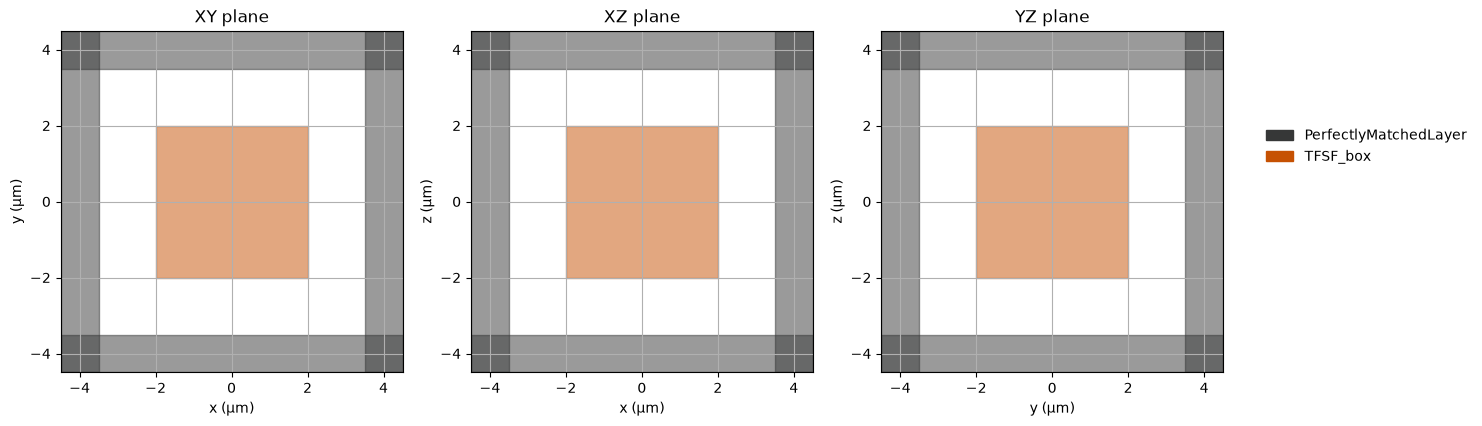

In [23]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()

The TFSF box should sit in the center of the volume with plenty of room to the PML. Nothing else is in the scene yet. We can also plot the pulse the source will emit, in time and as a spectrum.

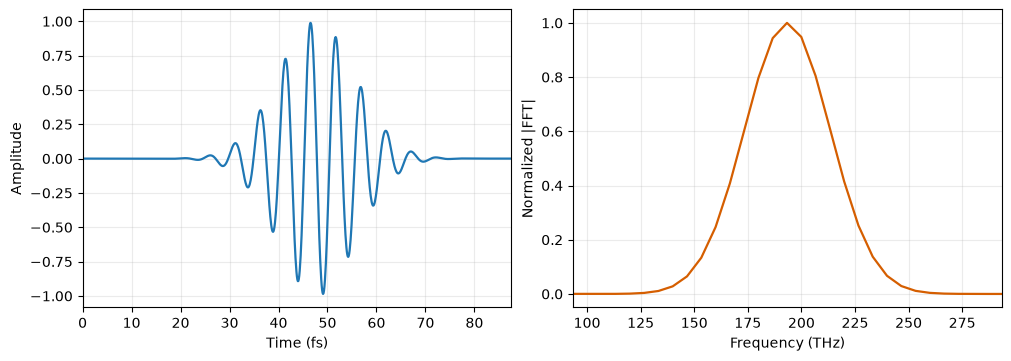

In [26]:
fig = objects["TFSF_box"].plot_time_signal_and_spectrum(config=config)
plt.show()

## 7. Test 1: an empty box

Before adding a scatterer we run the empty box. With nothing inside to scatter the wave, the field outside the box should be zero, and only the interior should light up.

An fdtdx run has two parts. `apply_params` prepares the parametric objects (there are none here) and precomputes some values, and `run_fdtd` does the time stepping.

In [29]:
def sim_fn(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


start_time = time.time()
jitted_sim = jax.jit(sim_fn).lower(params, arrays, key).compile()
print(f"Compilation time: {time.time() - start_time:.1f} s")

Compilation time: 0.6 s


In [31]:
start_time = time.time()
new_arrays_empty = jitted_sim(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - start_time:.1f} s")

FDTD (checkpointed):   0%|                           | 0/1574 [00:00<?, ?step/s]

Simulation runtime: 47.7 s


In [35]:
video_path_empty = objects["Video"].draw_plot(new_arrays_empty.detector_states["Video"])
Video(list(video_path_empty.values())[0], embed=True, width=720)

The pulse enters the box through the lower face, travels along +z and leaves through the upper face. Outside the box the plot stays dark. The thin bright outline along the edge of the box is not leaked light, and the next section explains what it is.

## 8. How dark is the outside?

A dark plot depends on the color scale, so let us measure it. The function below compares the peak energy density outside the box with the peak energy density inside. `margin` is the number of cells next to the box surface that are left out of the "outside" region. The PML is always excluded.

In [39]:
def outside_to_inside_ratio(detector_state, margin):
    # The detector plane "XZ Plane" is averaged over y, so it has shape (frames, nx, nz).
    (x0, x1), _, (z0, z1) = objects["TFSF_box"].grid_slice_tuple
    energy = np.asarray(detector_state["XZ Plane"])
    nx, nz = energy.shape[1:]

    inside = np.zeros((nx, nz), dtype=bool)
    inside[x0:x1, z0:z1] = True

    outside = np.zeros((nx, nz), dtype=bool)
    outside[pml_cells : nx - pml_cells, pml_cells : nz - pml_cells] = True
    outside[x0 - margin : x1 + margin, z0 - margin : z1 + margin] = False

    return energy[:, outside].max() / energy[:, inside].max()


empty_state = new_arrays_empty.detector_states["Video"]
for margin in (0, 1, 2):
    print(f"margin {margin} cells: peak energy outside / inside = {outside_to_inside_ratio(empty_state, margin):.1e}")

margin 0 cells: peak energy outside / inside = 2.5e-01
margin 1 cells: peak energy outside / inside = 5.0e-04
margin 2 cells: peak energy outside / inside = 5.0e-04


There are two different effects in these numbers.

Directly at the surface (margin 0) the ratio is about 0.25. This is the bright outline in the video. The detector computes the energy of a cell from E and H, which live on staggered positions of the Yee grid, so cells that touch the box surface combine values from both sides of it. We do not read it as light that has escaped. It is gone after one cell (margin 1), where the ratio drops by roughly three orders of magnitude.

What remains beyond that is a real, but small, leftover of order 1e-4 to 1e-3 in energy. It comes from numerical dispersion. The TFSF correction injects an analytic plane wave with the vacuum phase velocity, but a wave on the Yee grid travels slightly slower. At the entry face the two agree. Along the way through the box the phase of the grid wave falls behind, and at the exit face the correction no longer cancels the wave exactly. The mismatch leaves the box as a weak copy of the pulse behind the exit face, and a smaller amount leaks through the side faces.

For a wave along an axis, the grid wavenumber follows from the Yee dispersion relation, so we can estimate the phase error accumulated over the box length.

In [42]:
c0 = 299792458.0
h = config.uniform_spacing()
dt = config.time_step_duration
wavelength = 1.55e-6
box_length = 4e-6

omega = 2 * np.pi * c0 / wavelength
k_vacuum = omega / c0
k_grid = (2 / h) * np.arcsin(np.sin(omega * dt / 2) * h / (c0 * dt))

phase_error = (k_grid - k_vacuum) * box_length
print(f"grid phase velocity / c: {k_vacuum / k_grid:.4f}")
print(f"phase error over the box: {phase_error:.3f} rad")
print(f"expected leftover in energy, (phase error)^2: {phase_error**2:.1e}")

grid phase velocity / c: 0.9988
phase error over the box: 0.019 rad
expected leftover in energy, (phase error)^2: 3.5e-04


The estimate is close to the measured leftover at margin 1 and above. It also explains how to reduce it. The phase error grows linearly with the length of the box and falls with the square of the grid spacing. In a test run with a continuous wave, a 6 µm box on a 100 nm grid leaked about 13 % of the incident field amplitude, which is easy to see in a video. Halving the spacing reduced this to about 3 %, and the 4 µm box on a 50 nm grid used here brings the leftover energy to a few times 1e-4. If the scattered field you care about is weak, keep the box only as large as the scatterer needs and use a fine grid.

## 9. Test 2: adding a scatterer

Now we put something in the box: a silicon cube with 1.2 µm edge length, centered in the TFSF box.

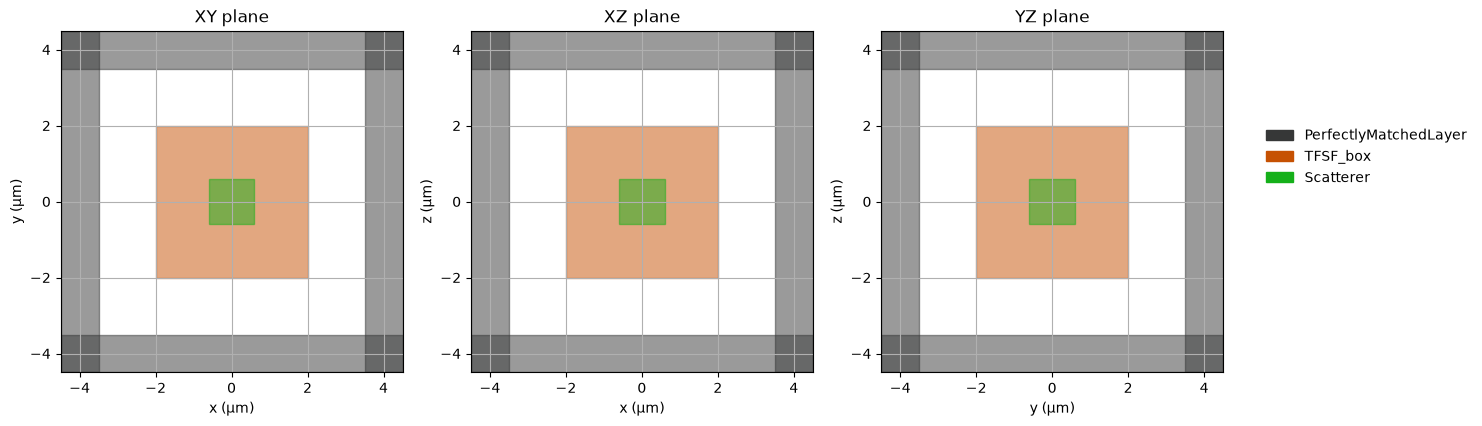

In [46]:
scatterer = fdtdx.UniformMaterialObject(
    partial_real_shape=(1.2e-6, 1.2e-6, 1.2e-6),
    material=fdtdx.Material(permittivity=fdtdx.constants.relative_permittivity_silicon),
    name="Scatterer",
    color=fdtdx.colors.GREEN,
)

object_list_2 = object_list + [scatterer]
constraints_2 = constraints + [scatterer.place_at_center(tfsf_box)]

key, subkey = jax.random.split(key)
objects2, arrays2, params2, config2, _ = fdtdx.place_objects(
    object_list=object_list_2,
    config=config,
    constraints=constraints_2,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config2,
    objects=objects2,
    exclude_object_list=[video_energy_detector],
)
plt.show()

In [48]:
def sim_fn_scatter(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects2, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config2,
        key=key,
    )
    _, arrays = final_state
    return arrays


jitted_sim_scatter = jax.jit(sim_fn_scatter).lower(params2, arrays2, key).compile()
new_arrays_scatter = jitted_sim_scatter(params2, arrays2, subkey)

FDTD (checkpointed):   0%|                           | 0/1574 [00:00<?, ?step/s]

In [50]:
video_path_scatter = objects2["Video"].draw_plot(new_arrays_scatter.detector_states["Video"])
Video(list(video_path_scatter.values())[0], embed=True, width=720)

Inside the box the pulse travels as before. When it reaches the cube, part of it is scattered, and this scattered light crosses the box surface and spreads out in all directions towards the PML, not just forward as it would with a plain plane source. What you see outside the box is only the scattered field, which is what you would pass on to a far-field projection or a cross-section calculation. We can compare it with the empty box using the same measure as before.

In [53]:
scatter_state = new_arrays_scatter.detector_states["Video"]
ratio_empty = outside_to_inside_ratio(empty_state, margin=2)
ratio_scatter = outside_to_inside_ratio(scatter_state, margin=2)
print(f"empty box:    peak energy outside / inside = {ratio_empty:.1e}")
print(f"with cube:    peak energy outside / inside = {ratio_scatter:.1e}")
print(f"ratio of the two: {ratio_scatter / ratio_empty:.0f}x")

empty box:    peak energy outside / inside = 5.0e-04
with cube:    peak energy outside / inside = 3.5e-02
ratio of the two: 70x
